# Disabling decay feedback

In [1]:
import json
import math
import sys
import os

In [2]:
proj_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(proj_root)

In [3]:
import warnings

warnings.filterwarnings("ignore")

In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Setting up for experiments (don't change this cell -- default parameters shouldn't change)
from src.caries_20220319 import CariesV2
from src.tools.Experiment import Experiment
from src.tools.sample import Range, Values, Sample

from src.tools.DataDict import DataDict

In [6]:
parameters = {
        # Number of kids
        'agents': 2500,
        # Number of steps in the simulation
        'steps': 36,
        # Model will record every n-th step
        'record_steps': 1,
        # Random seed - can be set to None
        'seed': 17,
        # Main decay/filled/missing/sound parameters
        'person_decay_prob': 0.01356,
        'person_filling_prob': 0.00996,
        'sound_to_cavitated': 0.008994,
        'cavitated_to_missing': 0.00848,
        'person_decay_feedback': 0.25,
        # Fluoride parameters
        'fluoride_effect': 1.00,
        'fluoride_slope': 3.00,
        'fluoride_months_effective': 6.00,
        'person_preventive_fluoride': 1.00,
        'fluoride_scenario': 3.00,
        # High-risk Kid initialization parameters
        'init_caries_prevalence': 0.215311,
        'init_caries_prob': 0.16,
        'init_missing_prob': 0.00848,
        # Behavioral decay parameters
        'behavioral_decay': -1,
        'behavioral_feedback': 1,
        'disable_decay': 0,
    }

## Setting (hyper)parameters

In [7]:
experiment_name = 'greatercare_figuredata_origFeedback_run_filled_missing_2500agents_30reps_nofeedback'


num_agents = 2500

# Iterations per sample
num_iterations = 30 
num_jobs = 1 #changes number of parallel runs (cpu usage)

exp_parameters = parameters.copy()



# Change number of steps between recording
exp_parameters['record_steps'] = 36 # This means the model will record every 36 steps (only at the beginning/end)

# Change this for percentage of initial high risk
# exp_parameters['init_caries_prevalence'] = 1.00 # all high risk

# Setting behavioral decay to the old default
exp_parameters['behavioral_decay'] = -1 

# Changing fluoride settings
exp_parameters['fluoride_scenario'] = 2.00 
exp_parameters['person_preventive_fluoride'] = 0.1 # Talk about this value
exp_parameters['fluoride_effect'] = 0.1 # and this value

# Changing the number of agents (faster run-time)
exp_parameters['agents'] = num_agents

# Setting the random seed
exp_parameters['seed'] = None

# Setting up sample ranges
range_filling_prob = Values(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0) #Values(0.005, 0.00996, 0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2)
num_steps = num_samples = len(range_filling_prob)
# range_missing_prob = Range(vmin=0, vmax=0.2)

exp_parameters['person_filling_prob'] = range_filling_prob
# exp_parameters['cavitated_to_missing'] = range_missing_prob
# exp_parameters['cavitated_to_missing'] =  0.0848
exp_parameters['disable_decay'] = 1

exp_samples = Sample(parameters=exp_parameters, n=num_steps)

In [8]:
len(range_filling_prob)

9

## Running the experiment

In [9]:
from src.caries_20220319 import CariesV2
from src.tools.Experiment import Experiment
from src.tools.sample import Range, Values, Sample
# Don't run this cell unless doing an experiment (experiments can take a while)
exp = Experiment(CariesV2, sample=exp_samples, iterations=num_iterations, record=True)
results = exp.run(n_jobs=num_jobs)
results.save(exp_name=experiment_name)

Scheduled runs: 270
Completed: 270, estimated time remaining: 0:00:00
Experiment finished
Run time: 0:10:33.737481
Data is saved to model_output/greatercare_figuredata_origFeedback_run_filled_missing_2500agents_30reps_nofeedback_1


# Data Output Processing
Calculating the variables and metrics that we want to analyze.

Different samples ranges and experiment data need differing treatment.

In [10]:
# Import data -- make sure exp_name is correct (takes from model_output folder and latest exp_id -- see README)
data_filled_missing = DataDict().load(exp_name=experiment_name) # set exp_id=:int: for specific choice

# extracting the desired dataframe (see README section to understand multi-index)
# df = results.variables.Kid
df = data_filled_missing.variables.Kid 

# param_samples = results.parameters.sample
param_samples = data_filled_missing.parameters.sample #checking the parameter samples

Loading from directory model_output/greatercare_figuredata_origFeedback_run_filled_missing_2500agents_30reps_nofeedback_1/
Loading info.json - Successful
Loading parameters_constants.json - Successful
Loading parameters_log.json - Successful
Loading parameters_sample.csv - Successful
Loading reporters.csv - Successful
Loading variables_Kid.csv - Successful


In [11]:
labels = param_samples.loc[:num_steps-1, "person_filling_prob"]
labels = labels.round(5)

In [12]:
missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_missing_per_sample_id = np.array([missing_df.loc[id].sum() for id in range(num_samples)]) 

filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_filled_per_sample_id = np.array([filled_df.loc[id].sum() for id in range(num_samples)])

caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = np.array([caries_df.loc[id].sum() for id in range(num_samples)])

# Select all three relevant columns at time=36
all_df = df.loc[(slice(None), slice(None), slice(None), 36), ['missing', 'filled', 'caries']]

# Add a new column that is the sum of the three components (i.e., DMFT index)
dmft_df = all_df.sum(axis=1)
metric_df = all_df['caries'] + 2 * all_df['missing'] + 0.5 * all_df['filled']

hi_df = df.loc[df['high_risk'] == 1]

hi_missing_df = hi_df.loc[(slice(None), slice(None), slice(None), 36), 'missing']

hi_filled_df = hi_df.loc[(slice(None), slice(None), slice(None), 36), 'filled']

hi_caries_df = hi_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']

# Select all three relevant columns at time=36
hi_all_df = hi_df.loc[(slice(None), slice(None), slice(None), 36), ['missing', 'filled', 'caries']]

# Add a new column that is the sum of the three components (i.e., DMFT index)
hi_dmft_df = hi_all_df.sum(axis=1)
hi_metric_df = hi_all_df['caries'] + 2 * hi_all_df['missing'] + 0.5 * hi_all_df['filled']

lo_df = df.loc[df['high_risk'] == 0]

lo_missing_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'missing']

lo_filled_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'filled']

lo_caries_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']

# Select all three relevant columns at time=36
lo_all_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), ['missing', 'filled', 'caries']]

# Add a new column that is the sum of the three components (i.e., DMFT index)
lo_dmft_df = lo_all_df.sum(axis=1)
lo_metric_df = lo_all_df['caries'] + 2 * lo_all_df['missing'] + 0.5 * lo_all_df['filled']



In [13]:
# Step 1: Select relevant columns at t = 36
subset_df = df.loc[(slice(None), slice(None), slice(None), 36), ['high_risk', 'missing', 'filled', 'caries']]

# Step 2: Add computed columns
subset_df = subset_df.copy()
subset_df['dmft'] = subset_df[['missing', 'filled', 'caries']].sum(axis=1)
subset_df['metric'] = subset_df['caries'] + 2 * subset_df['missing'] + 0.5 * subset_df['filled']

grouped = subset_df.groupby(['sample_id', 'iteration', 'high_risk']).sum()
grouped['count'] = subset_df.groupby(['sample_id', 'iteration', 'high_risk']).size()
unstacked = grouped.unstack(level='high_risk')

unstacked['disp_missing'] = (unstacked['missing'][1]/unstacked['count'][1]) - (unstacked['missing'][0]/unstacked['count'][0])
unstacked['disp_filled'] = (unstacked['filled'][1]/unstacked['count'][1]) - (unstacked['filled'][0]/unstacked['count'][0])
unstacked['disp_caries'] = (unstacked['caries'][1]/unstacked['count'][1]) - (unstacked['caries'][0]/unstacked['count'][0])
unstacked['disp_dmft'] = (unstacked['dmft'][1]/unstacked['count'][1]) - (unstacked['dmft'][0]/unstacked['count'][0])
unstacked['disp_metric'] = (unstacked['metric'][1]/unstacked['count'][1]) - (unstacked['metric'][0]/unstacked['count'][0])

disp_mean = unstacked.groupby(['sample_id']).mean()[['disp_missing', 'disp_filled', 'disp_caries', 'disp_dmft', 'disp_metric']]
disp_std = unstacked.groupby(['sample_id']).std()[['disp_missing', 'disp_filled', 'disp_caries', 'disp_dmft', 'disp_metric']]
disp_mean = disp_mean.add_suffix('_mean')
disp_std = disp_std.add_suffix('_std')

disparity_summary = pd.concat([disp_mean, disp_std], axis=1)
disparity_summary.columns = disparity_summary.columns.get_level_values(0)

In [14]:
# STEP 1: Compute sample-wise means (still the same)
missing_mean_per_sample = missing_df.groupby(level='sample_id').mean()
filled_mean_per_sample = filled_df.groupby(level='sample_id').mean()
caries_mean_per_sample = caries_df.groupby(level='sample_id').mean()
dmft_mean_per_sample = dmft_df.groupby(level='sample_id').mean()
metric_mean_per_sample = metric_df.groupby(level='sample_id').mean()

# STEP 2: Compute std across iteration means

# Collapse obj_id by taking the mean for each (sample_id, iteration)
missing_mean_per_iter = missing_df.groupby(['sample_id', 'iteration']).mean()
filled_mean_per_iter = filled_df.groupby(['sample_id', 'iteration']).mean()
caries_mean_per_iter = caries_df.groupby(['sample_id', 'iteration']).mean()
dmft_mean_per_iter = dmft_df.groupby(['sample_id', 'iteration']).mean()
metric_mean_per_iter = metric_df.groupby(['sample_id', 'iteration']).mean()

# Then compute std across iterations (per sample_id)
missing_std_per_sample = missing_mean_per_iter.groupby('sample_id').std()
filled_std_per_sample = filled_mean_per_iter.groupby('sample_id').std()
caries_std_per_sample = caries_mean_per_iter.groupby('sample_id').std()
dmft_std_per_sample = dmft_mean_per_iter.groupby('sample_id').std()
metric_std_per_sample = metric_mean_per_iter.groupby('sample_id').std()

# STEP 1: Compute sample-wise means (still the same)
hi_missing_mean_per_sample = hi_missing_df.groupby(level='sample_id').mean()
hi_filled_mean_per_sample = hi_filled_df.groupby(level='sample_id').mean()
hi_caries_mean_per_sample = hi_caries_df.groupby(level='sample_id').mean()
hi_dmft_mean_per_sample = hi_dmft_df.groupby(level='sample_id').mean()
hi_metric_mean_per_sample = hi_metric_df.groupby(level='sample_id').mean()

# STEP 2: Compute std across iteration means

# Collapse obj_id by taking the mean for each (sample_id, iteration)
hi_missing_mean_per_iter = hi_missing_df.groupby(['sample_id', 'iteration']).mean()
hi_filled_mean_per_iter = hi_filled_df.groupby(['sample_id', 'iteration']).mean()
hi_caries_mean_per_iter = hi_caries_df.groupby(['sample_id', 'iteration']).mean()
hi_dmft_mean_per_iter = hi_dmft_df.groupby(['sample_id', 'iteration']).mean()
hi_metric_mean_per_iter = hi_metric_df.groupby(['sample_id', 'iteration']).mean()

# Then compute std across iterations (per sample_id)
hi_missing_std_per_sample = hi_missing_mean_per_iter.groupby('sample_id').std()
hi_filled_std_per_sample = hi_filled_mean_per_iter.groupby('sample_id').std()
hi_caries_std_per_sample = hi_caries_mean_per_iter.groupby('sample_id').std()
hi_dmft_std_per_sample = hi_dmft_mean_per_iter.groupby('sample_id').std()
hi_metric_std_per_sample = hi_metric_mean_per_iter.groupby('sample_id').std()

# STEP 1: Compute sample-wise means (still the same)
lo_missing_mean_per_sample = lo_missing_df.groupby(level='sample_id').mean()
lo_filled_mean_per_sample = lo_filled_df.groupby(level='sample_id').mean()
lo_caries_mean_per_sample = lo_caries_df.groupby(level='sample_id').mean()
lo_dmft_mean_per_sample = lo_dmft_df.groupby(level='sample_id').mean()
lo_metric_mean_per_sample = lo_metric_df.groupby(level='sample_id').mean()

# STEP 2: Compute std across iteration means

# Collapse obj_id by taking the mean for each (sample_id, iteration)
lo_missing_mean_per_iter = lo_missing_df.groupby(['sample_id', 'iteration']).mean()
lo_filled_mean_per_iter = lo_filled_df.groupby(['sample_id', 'iteration']).mean()
lo_caries_mean_per_iter = lo_caries_df.groupby(['sample_id', 'iteration']).mean()
lo_dmft_mean_per_iter = lo_dmft_df.groupby(['sample_id', 'iteration']).mean()
lo_metric_mean_per_iter = lo_metric_df.groupby(['sample_id', 'iteration']).mean()

# Then compute std across iterations (per sample_id)
lo_missing_std_per_sample = lo_missing_mean_per_iter.groupby('sample_id').std()
lo_filled_std_per_sample = lo_filled_mean_per_iter.groupby('sample_id').std()
lo_caries_std_per_sample = lo_caries_mean_per_iter.groupby('sample_id').std()
lo_dmft_std_per_sample = lo_dmft_mean_per_iter.groupby('sample_id').std()
lo_metric_std_per_sample = lo_metric_mean_per_iter.groupby('sample_id').std()

# Assemble final summary DataFrame
summary_df = pd.DataFrame({
    'missing_mean': missing_mean_per_sample,
    'missing_std': missing_std_per_sample,
    'filled_mean': filled_mean_per_sample,
    'filled_std': filled_std_per_sample,
    'caries_mean': caries_mean_per_sample,
    'caries_std': caries_std_per_sample,
    'dmft_mean': dmft_mean_per_sample,
    'dmft_std': dmft_std_per_sample,
    'metric_mean': metric_mean_per_sample,
    'metric_std': metric_std_per_sample,
    # High-risk group
    'hi_missing_mean': hi_missing_mean_per_sample,
    'hi_missing_std': hi_missing_std_per_sample,
    'hi_filled_mean': hi_filled_mean_per_sample,
    'hi_filled_std': hi_filled_std_per_sample,
    'hi_caries_mean': hi_caries_mean_per_sample,
    'hi_caries_std': hi_caries_std_per_sample,
    'hi_dmft_mean': hi_dmft_mean_per_sample,
    'hi_dmft_std': hi_dmft_std_per_sample,
    'hi_metric_mean': hi_metric_mean_per_sample,
    'hi_metric_std': hi_metric_std_per_sample,

    # lo-risk group
    'lo_missing_mean': lo_missing_mean_per_sample,
    'lo_missing_std': lo_missing_std_per_sample,
    'lo_filled_mean': lo_filled_mean_per_sample,
    'lo_filled_std': lo_filled_std_per_sample,
    'lo_caries_mean': lo_caries_mean_per_sample,
    'lo_caries_std': lo_caries_std_per_sample,
    'lo_dmft_mean': lo_dmft_mean_per_sample,
    'lo_dmft_std': lo_dmft_std_per_sample,
    'lo_metric_mean': lo_metric_mean_per_sample,
    'lo_metric_std': lo_metric_std_per_sample,
})

summary_df = pd.concat([summary_df, disparity_summary], axis=1)

# Relabel index from sample_id to filling_prob
summary_df.index = labels
summary_df.index.name = 'person_filling_prob'

summary_df

,missing_mean,missing_std,filled_mean,filled_std,caries_mean,caries_std,dmft_mean,dmft_std,metric_mean,metric_std,...,disp_missing_mean,disp_filled_mean,disp_caries_mean,disp_dmft_mean,disp_metric_mean,disp_missing_std,disp_filled_std,disp_caries_std,disp_dmft_std,disp_metric_std
person_filling_prob,,,,,,,,,,,,,,,,,,,,,
0.30,0.061320,0.005078,1.357240,0.042460,0.050627,0.004498,1.469187,0.044838,0.851887,0.027408,...,0.236353,3.960884,-0.003406,4.193831,2.449743,0.019496,0.067728,0.012257,0.068915,0.050593
0.40,0.051907,0.004006,1.391320,0.039994,0.037787,0.004125,1.481013,0.042568,0.837260,0.025646,...,0.208391,4.016702,0.001558,4.226650,2.426691,0.016603,0.073518,0.011059,0.079470,0.055420
0.50,0.046813,0.004436,1.405973,0.057928,0.032373,0.004641,1.485160,0.059601,0.828987,0.032946,...,0.196058,3.996366,0.000703,4.193127,2.391002,0.018343,0.083109,0.009954,0.090366,0.063297
0.60,0.043880,0.005168,1.410760,0.043671,0.026467,0.002971,1.481107,0.046858,0.819607,0.028444,...,0.189345,4.000294,0.000209,4.189849,2.379047,0.020837,0.082893,0.007339,0.078341,0.049403
0.70,0.038680,0.003542,1.400667,0.037409,0.022027,0.003441,1.461373,0.039273,0.799720,0.023205,...,0.170953,4.016191,-0.001043,4.186102,2.348959,0.013229,0.074236,0.008965,0.077914,0.049634
0.80,0.038440,0.004214,1.415293,0.050274,0.019373,0.003562,1.473107,0.049981,0.803900,0.026952,...,0.172678,4.002493,0.000358,4.175530,2.346961,0.020547,0.091345,0.007389,0.098411,0.068929
0.90,0.035107,0.003520,1.416293,0.033486,0.017773,0.001987,1.469173,0.032814,0.796133,0.016574,...,0.161396,4.033205,0.000119,4.194720,2.339513,0.016272,0.075815,0.007227,0.077328,0.048183
0.95,0.035107,0.004604,1.418133,0.043749,0.017667,0.002988,1.470907,0.047515,0.796947,0.029328,...,0.160172,4.006257,-0.000611,4.165818,2.322862,0.018631,0.085637,0.006529,0.092054,0.064193
1.00,0.033907,0.003440,1.411147,0.032441,0.015227,0.002969,1.460280,0.033437,0.788613,0.018462,...,0.159421,4.032388,-0.000977,4.190832,2.334060,0.016622,0.067317,0.007188,0.068287,0.046448


In [15]:
summary_df.to_csv("greatercare_OrigFeedback_Figure_NoFeedback.csv")

In [16]:
# OLD CODE BELOW - ignore

In [17]:
# We are only looking at the last time step (t=36)
missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']

In [18]:
sum_missing_per_sample_id = [missing_df.loc[id].sum() for id in range(num_samples)] 

filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_filled_per_sample_id = [filled_df.loc[id].sum() for id in range(num_samples)]

caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = [caries_df.loc[id].sum() for id in range(num_samples)]

In [19]:
caries_df

sample_id  iteration  obj_id  t 
0          0          1       36    0
                      2       36    0
                      3       36    0
                      4       36    0
                      5       36    0
                                   ..
8          29         2496    36    0
                      2497    36    0
                      2498    36    0
                      2499    36    0
                      2500    36    0
Name: caries, Length: 675000, dtype: int64

In [20]:
avg_missing = np.array([np.divide(s, num_iterations) for s in sum_missing_per_sample_id])
avg_filled = np.array([np.divide(s, num_iterations) for s in sum_filled_per_sample_id])
avg_caries = np.array([np.divide(s, num_iterations) for s in sum_caries_per_sample_id])

missing = np.divide(avg_missing, num_agents) 
filled = np.divide(avg_filled, num_agents)
caries = np.divide(avg_caries, num_agents)

total_caries = caries + missing + filled
metric = caries + 2*missing + 0.5*filled

# Organizing Data
Putting everything into DataFrames for ease of use with Matplotlib and Seaborn

In [21]:
labels = param_samples.loc[:num_steps-1, "person_filling_prob"]
labels = labels.round(3)

In [22]:
labels

sample_id
0    0.30
1    0.40
2    0.50
3    0.60
4    0.70
5    0.80
6    0.90
7    0.95
8    1.00
Name: person_filling_prob, dtype: float64

In [23]:
# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
df_line_missing_filled = pd.Series(missing, index=labels)
df_line_filled_filled = pd.Series(filled, index=labels)
df_line_caries_filled = pd.Series(caries, index=labels)
df_line_total_caries_filled = pd.Series(total_caries, index=labels)
# df_line_untreated_time_filled = pd.Series(avg_untreated_time, index=labels)
df_line_metric_filled = pd.Series(metric, index=labels)

# Grid of all plots

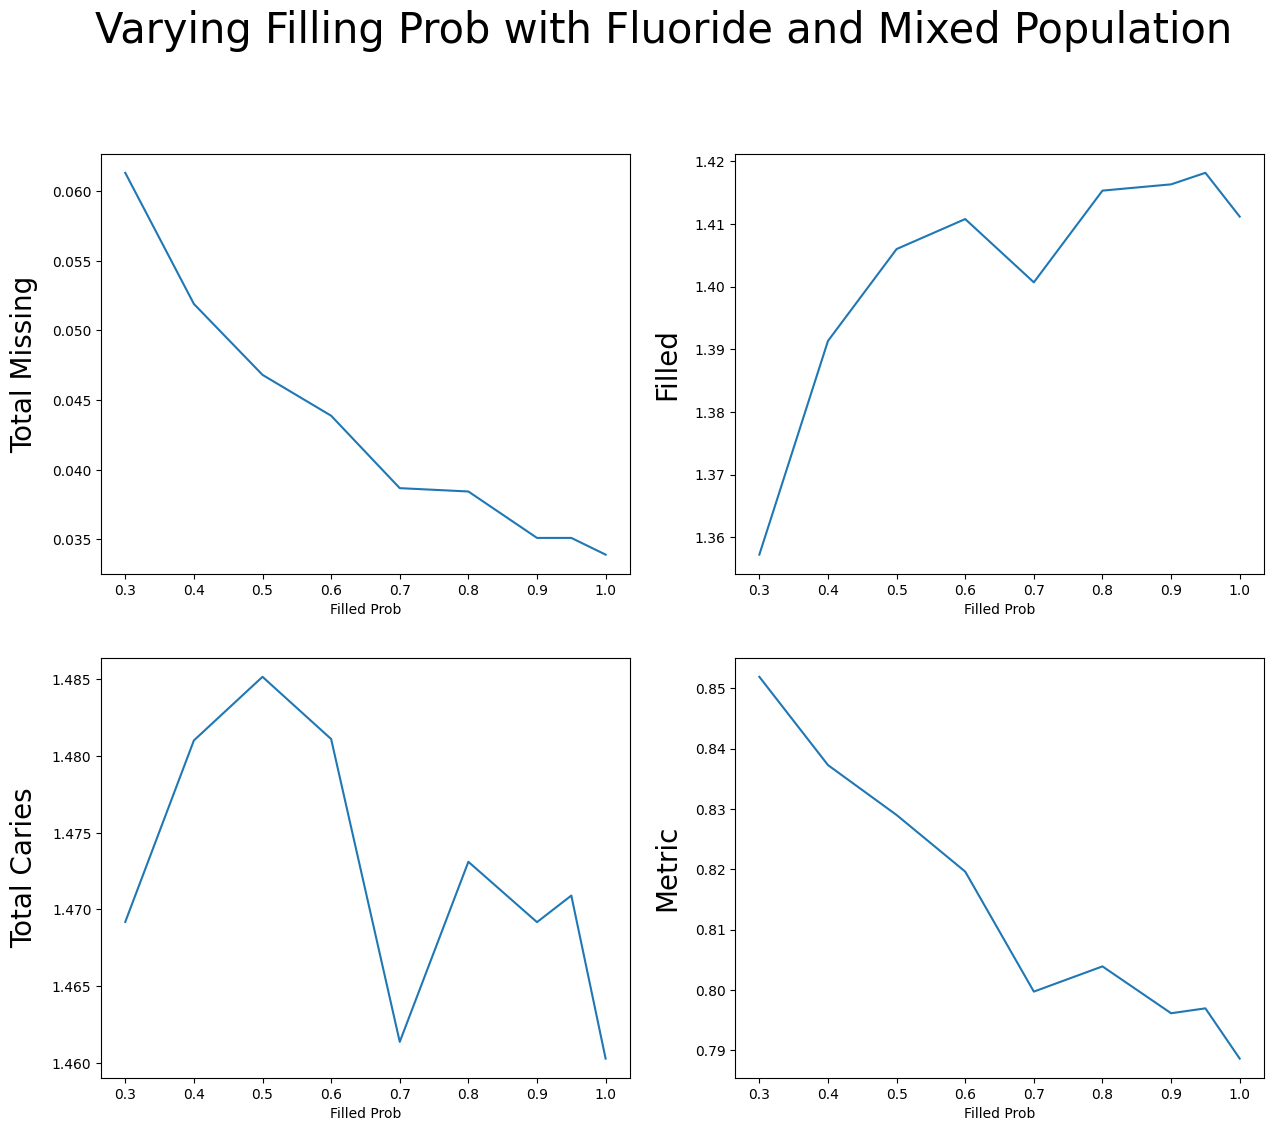

In [24]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Varying Filling Prob with Fluoride and Mixed Population", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Total Missing", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Filled", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Total Caries", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Metric", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].plot(df_line_missing_filled)
axs[0, 0].set_xlabel("Filled Prob")
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].plot(df_line_filled_filled)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].plot(df_line_total_caries_filled)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_caries_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].plot(df_line_metric_filled)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

In [25]:
df_line_missing_filled

person_filling_prob
0.30    0.061320
0.40    0.051907
0.50    0.046813
0.60    0.043880
0.70    0.038680
0.80    0.038440
0.90    0.035107
0.95    0.035107
1.00    0.033907
dtype: float64

# Untreated Decay Burden, Caries XP, and Disparity

In [26]:
num_Kids = exp_parameters['agents']
# --------------------------------------- #
#               Hi-Target                 #
# --------------------------------------- #
caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = [caries_df.loc[id].sum() for id in range(num_samples)]

caries_xp_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries_xp']
sum_caries_xp_per_sample_id = [caries_xp_df.loc[id].sum() for id in range(num_samples)]

lo_df = df.loc[df['high_risk'] == 0]

lo_caries_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_lo_caries_per_sample_id = [lo_caries_df.loc[id].sum() for id in range(num_samples)]

lo_caries_xp_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries_xp']
sum_lo_caries_xp_per_sample_id = np.divide(np.array([lo_caries_xp_df.loc[id].sum() for id in range(num_samples)]), num_iterations)

num_hi_Kids_df = df.loc[(slice(None), slice(None), slice(None), 36), 'high_risk']
num_hi_Kids_per_sample_id = np.divide(np.array([num_hi_Kids_df[id].sum() for id in range(num_samples)]), num_iterations)

num_lo_Kids_per_sample_id = np.full(num_samples, num_Kids) - num_hi_Kids_per_sample_id

In [27]:
# --------------------------------------- #
#               Hi-Target                 #
# --------------------------------------- #
avg_caries = np.array([np.divide(s, num_iterations*xp) for (s, xp) in zip(sum_caries_per_sample_id,sum_caries_xp_per_sample_id)])
avg_caries_xp = np.array([np.divide(s, num_iterations*num_Kids) for s in sum_caries_xp_per_sample_id])

sum_lo_caries_per_iteration = np.array([np.divide(s, num_iterations) for s in sum_lo_caries_per_sample_id])
sum_caries_per_iteration = np.array([np.divide(s, num_iterations) for s in sum_caries_per_sample_id])

avg_lo_caries = np.divide(sum_lo_caries_per_iteration, num_lo_Kids_per_sample_id)
avg_hi_caries = np.divide(sum_caries_per_iteration-sum_lo_caries_per_iteration, num_hi_Kids_per_sample_id)

avg_lo_caries_xp = np.divide(sum_lo_caries_xp_per_sample_id, num_lo_Kids_per_sample_id)

caries = avg_caries
caries_xp = avg_caries_xp
caries_disparity = avg_hi_caries - avg_lo_caries
caries_xp_disparity = np.ones(num_steps) - avg_lo_caries_xp

In [28]:
# --------------------------------------- #
#               Hi-Target                 #
# --------------------------------------- #

df_plt_caries = pd.Series(caries, index=labels)
df_plt_caries_xp = pd.Series(caries_xp, index=labels)

df_plt_caries_disparity = pd.Series(caries_disparity, index=labels)
df_plt_caries_xp_disparity = pd.Series(caries_xp_disparity, index=labels)

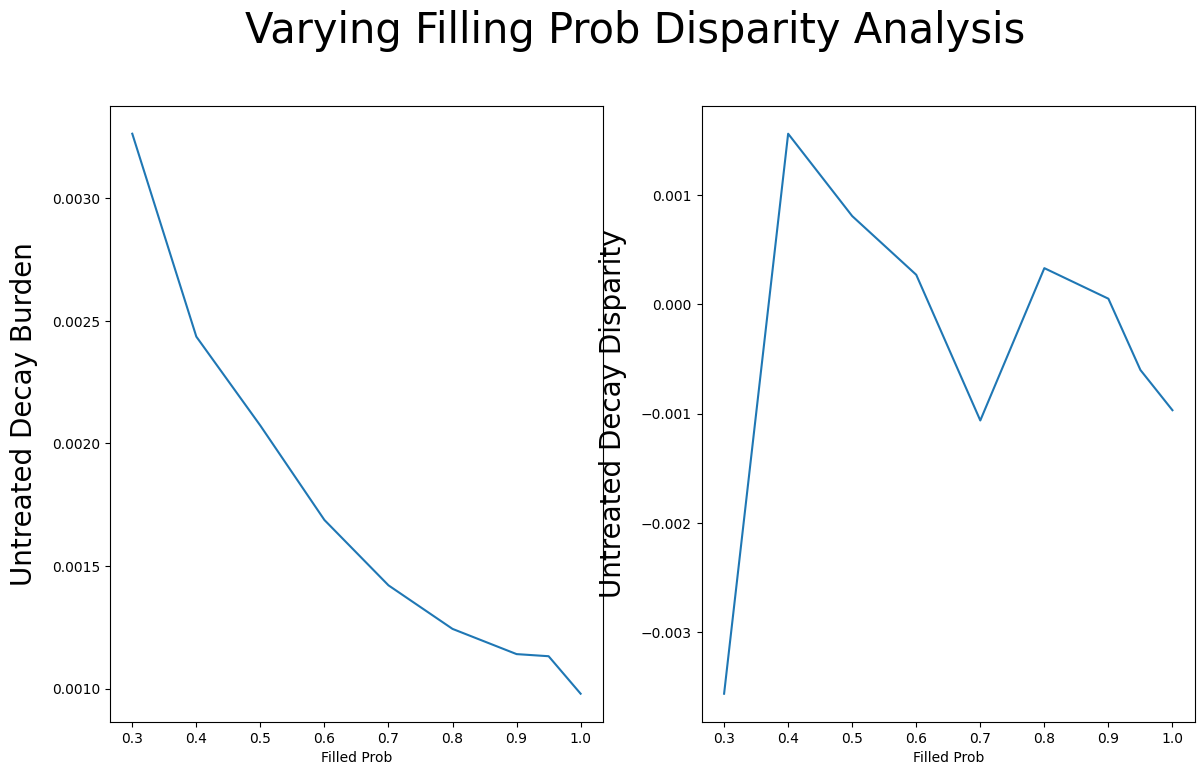

In [29]:
fig, axs = plt.subplots(1, 2)
fig.suptitle("Varying Filling Prob Disparity Analysis", fontsize=30, y=1, weight=500)
fig.set_size_inches(14, 8)
fig.set_dpi(100)


axs[0].set_ylabel("Untreated Decay Burden", fontsize=20, labelpad=10)
axs[1].set_ylabel("Untreated Decay Disparity", fontsize=20, labelpad=10)
# axs[1, 0].set_ylabel("Avg Caries XP", fontsize=20, labelpad=10)
# axs[1, 1].set_ylabel("Caries XP Disparity", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0].plot(df_plt_caries)
axs[0].set_xlabel("Filled Prob")

axs[1].plot(df_plt_caries_disparity)
axs[1].set_xlabel("Filled Prob")

# axs[1, 0].plot(df_plt_caries_xp)
# axs[1, 0].set_xlabel("Filled Prob")

# axs[1, 1].plot(df_plt_caries_xp_disparity)
# axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

# Average Time to Treatment

In [30]:
missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_missing_per_sample_id = np.array([missing_df.loc[id].sum() for id in range(num_samples)]) 

filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_filled_per_sample_id = np.array([filled_df.loc[id].sum() for id in range(num_samples)])

caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = np.array([caries_df.loc[id].sum() for id in range(num_samples)])

In [31]:
lo_missing_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_lo_missing_per_sample_id = np.array([lo_missing_df.loc[id].sum() for id in range(num_samples)]) 

lo_filled_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_lo_filled_per_sample_id = np.array([lo_filled_df.loc[id].sum() for id in range(num_samples)])

lo_caries_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_lo_caries_per_sample_id = np.array([lo_caries_df.loc[id].sum() for id in range(num_samples)])

In [32]:
total_caries_per_sample_id = sum_caries_per_sample_id + sum_filled_per_sample_id + sum_missing_per_sample_id
total_lo_caries_per_sample_id = sum_lo_caries_per_sample_id + sum_lo_filled_per_sample_id + sum_lo_missing_per_sample_id
total_hi_caries_per_sample_id = total_caries_per_sample_id - total_lo_caries_per_sample_id

untreated_time_df = df.loc[(slice(None), slice(None), slice(None), 36), 'untreated_time']
sum_untreated_time_per_sample_id = np.array([untreated_time_df.loc[id].sum() for id in range(num_samples)])

# untreated_time = np.array([np.divide(s, num_iterations) for s in sum_untreated_time_per_sample_id])
avg_untreated_time = np.divide(sum_untreated_time_per_sample_id, num_iterations * total_caries_per_sample_id)
# avg_untreated_time = np.divide(untreated_time, avg_missing + avg_filled + avg_caries)


lo_untreated_time_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'untreated_time']
sum_lo_untreated_time_per_sample_id = np.array([lo_untreated_time_df.loc[id].sum() for id in range(num_samples)])
sum_hi_untreated_time_per_sample_id = sum_untreated_time_per_sample_id - sum_lo_untreated_time_per_sample_id

avg_lo_untreated_time = np.divide(sum_lo_untreated_time_per_sample_id, num_iterations * total_lo_caries_per_sample_id)
avg_hi_untreated_time = np.divide(sum_hi_untreated_time_per_sample_id, num_iterations * total_hi_caries_per_sample_id)
untreated_time_disparity = avg_hi_untreated_time - avg_lo_untreated_time

df_untreated_time = pd.Series(avg_untreated_time, index=labels)
df_untreated_time_disparity = pd.Series(untreated_time_disparity, index=labels)

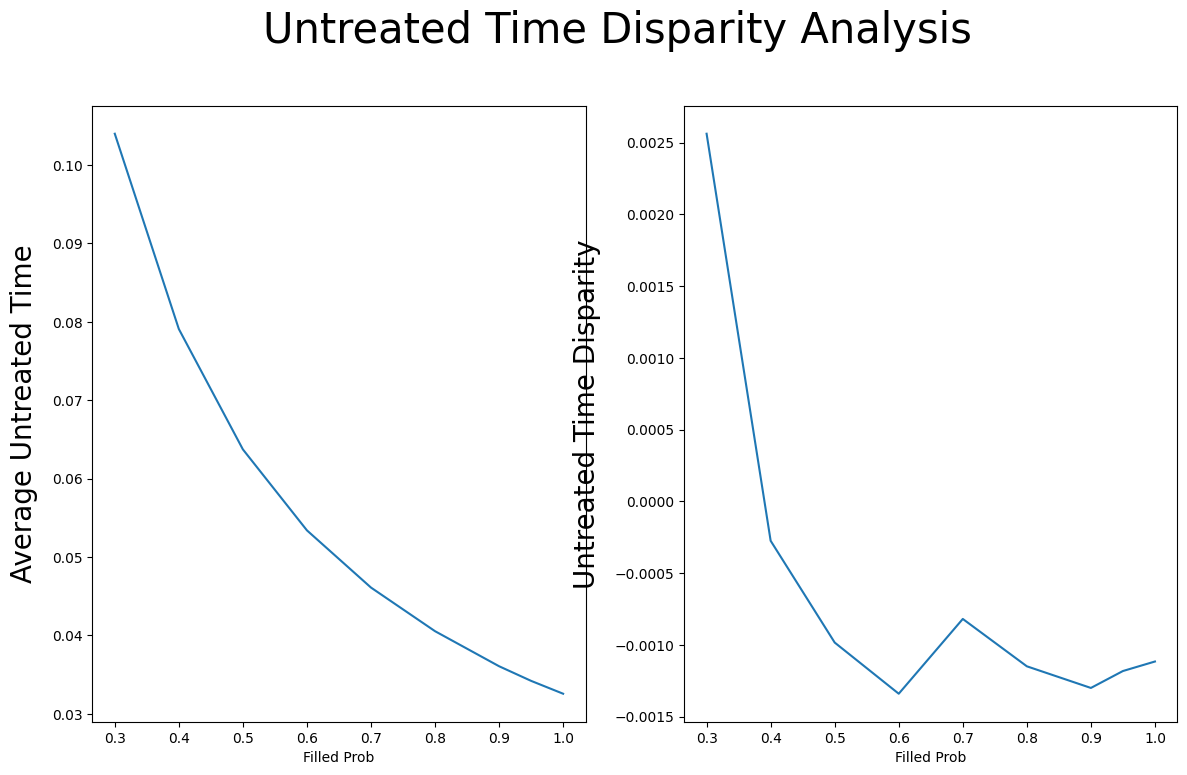

In [33]:
fig, axs = plt.subplots(1, 2)
fig.suptitle("Untreated Time Disparity Analysis", fontsize=30, y=1, weight=500)
fig.set_size_inches(14, 8)
fig.set_dpi(100)


axs[0].set_ylabel("Average Untreated Time", fontsize=20, labelpad=10)
axs[1].set_ylabel("Untreated Time Disparity", fontsize=20, labelpad=10)
# axs[1, 0].set_ylabel("Avg Caries XP", fontsize=20, labelpad=10)
# axs[1, 1].set_ylabel("Caries XP Disparity", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0].plot(df_untreated_time)
axs[0].set_xlabel("Filled Prob")

axs[1].plot(df_untreated_time_disparity)
axs[1].set_xlabel("Filled Prob")

# axs[1, 0].plot(df_plt_caries_xp)
# axs[1, 0].set_xlabel("Filled Prob")

# axs[1, 1].plot(df_plt_caries_xp_disparity)
# axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

# Other Disparities

In [34]:
missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_missing_per_sample_id = np.array([missing_df.loc[id].sum() for id in range(num_samples)]) 

filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_filled_per_sample_id = np.array([filled_df.loc[id].sum() for id in range(num_samples)])

caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = np.array([caries_df.loc[id].sum() for id in range(num_samples)])

# Select all three relevant columns at time=36
all_df = df.loc[(slice(None), slice(None), slice(None), 36), ['missing', 'filled', 'caries']]

# Add a new column that is the sum of the three components (i.e., DMFT index)
dmft_df = all_df.sum(axis=1)
metric_df = all_df['caries'] + 2 * all_df['missing'] + 0.5 * all_df['filled']

hi_df = df.loc[df['high_risk'] == 1]

hi_missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']

hi_filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']

hi_caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']

# Select all three relevant columns at time=36
hi_all_df = df.loc[(slice(None), slice(None), slice(None), 36), ['missing', 'filled', 'caries']]

# Add a new column that is the sum of the three components (i.e., DMFT index)
hi_dmft_df = all_df.sum(axis=1)
hi_metric_df = all_df['caries'] + 2 * all_df['missing'] + 0.5 * all_df['filled']

lo_df = df.loc[df['high_risk'] == 0]

lo_missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']

lo_filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']

lo_caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']

# Select all three relevant columns at time=36
lo_all_df = df.loc[(slice(None), slice(None), slice(None), 36), ['missing', 'filled', 'caries']]

# Add a new column that is the sum of the three components (i.e., DMFT index)
lo_dmft_df = all_df.sum(axis=1)
lo_metric_df = all_df['caries'] + 2 * all_df['missing'] + 0.5 * all_df['filled']

In [35]:
# STEP 1: Compute sample-wise means (still the same)
missing_mean_per_sample = missing_df.groupby(level='sample_id').mean()
filled_mean_per_sample = filled_df.groupby(level='sample_id').mean()
caries_mean_per_sample = caries_df.groupby(level='sample_id').mean()
dmft_mean_per_sample = dmft_df.groupby(level='sample_id').mean()
metric_mean_per_sample = metric_df.groupby(level='sample_id').mean()

# STEP 2: Compute std across iteration means

# Collapse obj_id by taking the mean for each (sample_id, iteration)
missing_mean_per_iter = missing_df.groupby(['sample_id', 'iteration']).mean()
filled_mean_per_iter = filled_df.groupby(['sample_id', 'iteration']).mean()
caries_mean_per_iter = caries_df.groupby(['sample_id', 'iteration']).mean()
dmft_mean_per_iter = dmft_df.groupby(['sample_id', 'iteration']).mean()
metric_mean_per_iter = metric_df.groupby(['sample_id', 'iteration']).mean()

# Then compute std across iterations (per sample_id)
missing_std_per_sample = missing_mean_per_iter.groupby('sample_id').std()
filled_std_per_sample = filled_mean_per_iter.groupby('sample_id').std()
caries_std_per_sample = caries_mean_per_iter.groupby('sample_id').std()
dmft_std_per_sample = dmft_mean_per_iter.groupby('sample_id').std()
metric_std_per_sample = metric_mean_per_iter.groupby('sample_id').std()

# HI / LO risk groups: mean across obj_id per sample
hi_missing_mean = hi_missing_df.groupby(level='sample_id').mean()
lo_missing_mean = lo_missing_df.groupby(level='sample_id').mean()
hi_metric_mean = hi_metric_df.groupby(level='sample_id').mean()
lo_metric_mean = lo_metric_df.groupby(level='sample_id').mean()

# HI / LO std: first mean across obj_id per iteration, then std across iterations
hi_missing_mean_per_iter = hi_missing_df.groupby(['sample_id', 'iteration']).mean()
lo_missing_mean_per_iter = lo_missing_df.groupby(['sample_id', 'iteration']).mean()
hi_metric_mean_per_iter = hi_metric_df.groupby(['sample_id', 'iteration']).mean()
lo_metric_mean_per_iter = lo_metric_df.groupby(['sample_id', 'iteration']).mean()

hi_missing_std = hi_missing_mean_per_iter.groupby('sample_id').std()
lo_missing_std = lo_missing_mean_per_iter.groupby('sample_id').std()
hi_metric_std = hi_metric_mean_per_iter.groupby('sample_id').std()
lo_metric_std = lo_metric_mean_per_iter.groupby('sample_id').std()

# Assemble final summary DataFrame
summary_df = pd.DataFrame({
    'missing_mean': missing_mean_per_sample,
    'missing_std': missing_std_per_sample,
    'filled_mean': filled_mean_per_sample,
    'filled_std': filled_std_per_sample,
    'caries_mean': caries_mean_per_sample,
    'caries_std': caries_std_per_sample,
    'dmft_mean': dmft_mean_per_sample,
    'dmft_std': dmft_std_per_sample,
    'metric_mean': metric_mean_per_sample,
    'metric_std': metric_std_per_sample,
})

# Relabel index from sample_id to filling_prob
summary_df.index = labels
summary_df.index.name = 'person_filling_prob'

summary_df


,missing_mean,missing_std,filled_mean,filled_std,caries_mean,caries_std,dmft_mean,dmft_std,metric_mean,metric_std
person_filling_prob,,,,,,,,,,
0.30,0.061320,0.005078,1.357240,0.042460,0.050627,0.004498,1.469187,0.044838,0.851887,0.027408
0.40,0.051907,0.004006,1.391320,0.039994,0.037787,0.004125,1.481013,0.042568,0.837260,0.025646
0.50,0.046813,0.004436,1.405973,0.057928,0.032373,0.004641,1.485160,0.059601,0.828987,0.032946
0.60,0.043880,0.005168,1.410760,0.043671,0.026467,0.002971,1.481107,0.046858,0.819607,0.028444
0.70,0.038680,0.003542,1.400667,0.037409,0.022027,0.003441,1.461373,0.039273,0.799720,0.023205
0.80,0.038440,0.004214,1.415293,0.050274,0.019373,0.003562,1.473107,0.049981,0.803900,0.026952
0.90,0.035107,0.003520,1.416293,0.033486,0.017773,0.001987,1.469173,0.032814,0.796133,0.016574
0.95,0.035107,0.004604,1.418133,0.043749,0.017667,0.002988,1.470907,0.047515,0.796947,0.029328
1.00,0.033907,0.003440,1.411147,0.032441,0.015227,0.002969,1.460280,0.033437,0.788613,0.018462


In [36]:
missing_df

sample_id  iteration  obj_id  t 
0          0          1       36    0
                      2       36    0
                      3       36    2
                      4       36    0
                      5       36    0
                                   ..
8          29         2496    36    0
                      2497    36    0
                      2498    36    0
                      2499    36    0
                      2500    36    0
Name: missing, Length: 675000, dtype: int64

In [37]:
# This groups all entries in missing_df by sample_id and computes the mean and std
missing_mean_per_sample = missing_df.groupby(level='sample_id').mean()
missing_std_per_sample = missing_df.groupby(level='sample_id').std()

filled_mean_per_sample = filled_df.groupby(level='sample_id').mean()
filled_std_per_sample = filled_df.groupby(level='sample_id').std()

caries_mean_per_sample = caries_df.groupby(level='sample_id').mean()
caries_std_per_sample = caries_df.groupby(level='sample_id').std()

dmft_mean_per_sample = dmft_df.groupby(level='sample_id').mean()
dmft_std_per_sample = dmft_df.groupby(level='sample_id').std()

metric_mean_per_sample = metric_df.groupby(level='sample_id').mean()
metric_std_per_sample = metric_df.groupby(level='sample_id').std()

hi_missing_mean = hi_missing_df.groupby(level='sample_id').mean()
hi_missing_std = hi_missing_df.groupby(level='sample_id').std()

lo_missing_mean = lo_missing_df.groupby(level='sample_id').mean()
lo_missing_std = lo_missing_df.groupby(level='sample_id').std()

hi_metric_mean = hi_metric_df.groupby(level='sample_id').mean()
hi_metric_std = hi_metric_df.groupby(level='sample_id').std()

lo_metric_mean = lo_metric_df.groupby(level='sample_id').mean()
lo_metric_std = lo_metric_df.groupby(level='sample_id').std()


In [38]:
# Step 1: mean over obj_id for each iteration
missing_mean_per_iteration = missing_df.groupby(['sample_id', 'iteration']).mean()

# Step 2: std across iterations (for each sample_id)
missing_std_across_iterations = missing_mean_per_iteration.groupby('sample_id').std()

# Optional: replace sample_id with filling prob labels
missing_std_across_iterations.index = labels
missing_std_across_iterations.index.name = 'person_filling_prob'

missing_std_across_iterations

person_filling_prob
0.30    0.005078
0.40    0.004006
0.50    0.004436
0.60    0.005168
0.70    0.003542
0.80    0.004214
0.90    0.003520
0.95    0.004604
1.00    0.003440
Name: missing, dtype: float64

In [39]:
summary_df = pd.DataFrame({
    'missing_mean': missing_mean_per_sample,
    'missing_std': missing_std_per_sample,
    'filled_mean': filled_mean_per_sample,
    'filled_std': filled_std_per_sample,
    'caries_mean': caries_mean_per_sample,
    'caries_std': caries_std_per_sample,
    'dmft_mean': dmft_mean_per_sample,
    'dmft_std': dmft_std_per_sample,
    'metric_mean': metric_mean_per_sample,
    'metric_std': metric_std_per_sample,
})
summary_df.index = labels
summary_df.index.name = 'person_filling_prob'

summary_df

,missing_mean,missing_std,filled_mean,filled_std,caries_mean,caries_std,dmft_mean,dmft_std,metric_mean,metric_std
person_filling_prob,,,,,,,,,,
0.30,0.061320,0.268404,1.357240,1.956096,0.050627,0.260380,1.469187,2.063373,0.851887,1.268185
0.40,0.051907,0.246387,1.391320,1.988373,0.037787,0.222320,1.481013,2.081132,0.837260,1.244237
0.50,0.046813,0.230440,1.405973,1.989281,0.032373,0.205311,1.485160,2.075610,0.828987,1.224868
0.60,0.043880,0.225289,1.410760,1.989227,0.026467,0.183612,1.481107,2.069427,0.819607,1.211501
0.70,0.038680,0.207552,1.400667,1.987004,0.022027,0.168430,1.461373,2.058661,0.799720,1.186359
0.80,0.038440,0.205984,1.415293,1.990684,0.019373,0.158277,1.473107,2.063014,0.803900,1.187606
0.90,0.035107,0.196794,1.416293,1.993484,0.017773,0.148922,1.469173,2.060081,0.796133,1.174313
0.95,0.035107,0.195980,1.418133,1.991379,0.017667,0.152474,1.470907,2.058345,0.796947,1.174190
1.00,0.033907,0.195578,1.411147,1.993342,0.015227,0.138113,1.460280,2.058167,0.788613,1.171034


In [40]:
std_missing_per_sample_id

NameError: name 'std_missing_per_sample_id' is not defined

In [ ]:
lo_missing_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_lo_missing_per_sample_id = np.array([lo_missing_df.loc[id].sum() for id in range(num_samples)]) 

lo_filled_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_lo_filled_per_sample_id = np.array([lo_filled_df.loc[id].sum() for id in range(num_samples)])

lo_caries_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_lo_caries_per_sample_id = np.array([lo_caries_df.loc[id].sum() for id in range(num_samples)])

In [ ]:
sum_hi_missing_per_sample_id = sum_missing_per_sample_id - sum_lo_missing_per_sample_id

sum_hi_filled_per_sample_id = sum_filled_per_sample_id - sum_lo_filled_per_sample_id

sum_hi_caries_per_sample_id = sum_caries_per_sample_id - sum_lo_caries_per_sample_id

In [ ]:
missing_disparity_per_sample_id = sum_hi_missing_per_sample_id - sum_lo_missing_per_sample_id

filled_disparity_per_sample_id = sum_hi_filled_per_sample_id - sum_lo_filled_per_sample_id

caries_disparity_per_sample_id = sum_hi_caries_per_sample_id - sum_lo_caries_per_sample_id

In [ ]:
missing_disparity = np.divide(missing_disparity_per_sample_id, num_agents* num_iterations) 
filled_disparity = np.divide(filled_disparity_per_sample_id, num_agents* num_iterations)
caries_disparity = np.divide(caries_disparity_per_sample_id, num_agents* num_iterations)
# missing_disparity = missing_disparity_per_sample_id
# filled_disparity = filled_disparity_per_sample_id
# caries_disparity = caries_disparity_per_sample_id

total_caries_disparity = missing_disparity + filled_disparity + caries_disparity
metric_disparity = caries_disparity + 2*missing_disparity + 0.5*filled_disparity

In [ ]:
df_line_missing_disparity = pd.Series(missing_disparity, index=labels)
df_line_filled_disparity = pd.Series(filled_disparity, index=labels)
df_line_total_caries_disparity = pd.Series(total_caries_disparity, index=labels)
df_line_metric_disparity = pd.Series(metric_disparity, index=labels)

In [ ]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Disparity analysis of varying treatment probabilities", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Missing Disparity", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Filled Disparity", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Caries Disparity", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Metric Disparity", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].plot(df_line_missing_disparity)
axs[0, 0].set_xlabel("Filled Prob")
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].plot(df_line_filled_disparity)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].plot(df_line_total_caries_disparity)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_untreated_time_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].plot(df_line_metric_disparity)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

In [ ]:
missing_lo = np.divide(sum_lo_missing_per_sample_id, num_lo_Kids_per_sample_id * num_iterations) 
filled_lo = np.divide(sum_lo_filled_per_sample_id, num_lo_Kids_per_sample_id * num_iterations)
caries_lo = np.divide(sum_lo_caries_per_sample_id, num_lo_Kids_per_sample_id * num_iterations)


total_caries_lo = missing_lo + filled_lo + caries_lo
metric_lo = caries_lo + 2*missing_lo + 0.5*filled_lo

missing_hi = np.divide(sum_hi_missing_per_sample_id, num_hi_Kids_per_sample_id * num_iterations) 
filled_hi = np.divide(sum_hi_filled_per_sample_id, num_hi_Kids_per_sample_id * num_iterations)
caries_hi = np.divide(sum_hi_caries_per_sample_id, num_hi_Kids_per_sample_id * num_iterations) # * num_iterations ?


total_caries_hi = missing_hi + filled_hi + caries_hi
metric_hi = caries_hi + 2*missing_hi + 0.5*filled_hi

In [ ]:
missing_lo

In [ ]:
std_missing_per_sample_id = np.array([missing_df.loc[id].std() for id in range(num_samples)]) 

std_filled_per_sample_id = np.array([filled_df.loc[id].std() for id in range(num_samples)])

std_caries_per_sample_id = np.array([caries_df.loc[id].std() for id in range(num_samples)])

std_lo_missing_per_sample_id = np.array([lo_missing_df.loc[id].std() for id in range(num_samples)]) 

std_lo_filled_per_sample_id = np.array([lo_filled_df.loc[id].std() for id in range(num_samples)])

std_lo_caries_per_sample_id = np.array([lo_caries_df.loc[id].std() for id in range(num_samples)])

hi_df = df.loc[df['high_risk'] == 1]

hi_missing_df = hi_df.loc[(slice(None), slice(None), slice(None), 36), 'missing']

hi_filled_df = hi_df.loc[(slice(None), slice(None), slice(None), 36), 'filled']

hi_caries_df = hi_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']

std_hi_missing_per_sample_id = np.array([hi_missing_df.loc[id].std() for id in range(num_samples)]) 

std_hi_filled_per_sample_id = np.array([hi_filled_df.loc[id].std() for id in range(num_samples)])

std_hi_caries_per_sample_id = np.array([hi_caries_df.loc[id].std() for id in range(num_samples)])

std_df_line_missing_lo = pd.Series(missing_lo, index=labels)
std_df_line_filled_lo = pd.Series(filled_lo, index=labels)
std_df_line_caries_lo = pd.Series(caries_lo, index=labels)
std_df_line_total_caries_lo = pd.Series(total_caries_lo, index=labels)
#std_df_line_metric_lo = pd.Series(metric_lo, index=labels)

std_df_line_missing_hi = pd.Series(missing_hi, index=labels)
std_df_line_filled_hi = pd.Series(filled_hi, index=labels)
std_df_line_caries_hi = pd.Series(caries_hi, index=labels)
std_df_line_total_caries_hi = pd.Series(total_caries_hi, index=labels)
#td_df_line_metric_hi = pd.Series(metric_hi, index=labels)

std_df_line_missing_all = pd.Series(std_missing_per_sample_id, index=labels)
std_df_line_filled_all = pd.Series(std_filled_per_sample_id, index=labels)
std_df_line_caries_all = pd.Series(std_caries_per_sample_id, index=labels)
std_df_line_total_caries_all = pd.Series(total_caries_hi, index=labels)
#td_df_line_metric_hi = pd.Series(metric_hi, index=labels)


In [ ]:
df_line_missing_lo = pd.Series(missing_lo, index=labels)
df_line_filled_lo = pd.Series(filled_lo, index=labels)
df_line_caries_lo = pd.Series(caries_lo, index=labels)
df_line_total_caries_lo = pd.Series(total_caries_lo, index=labels)
df_line_metric_lo = pd.Series(metric_lo, index=labels)

df_line_missing_hi = pd.Series(missing_hi, index=labels)
df_line_filled_hi = pd.Series(filled_hi, index=labels)
df_line_caries_hi = pd.Series(caries_hi, index=labels)
df_line_total_caries_hi = pd.Series(total_caries_hi, index=labels)
df_line_metric_hi = pd.Series(metric_hi, index=labels)

In [ ]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Disparity analysis of varying treatment probabilities", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Avg Missing per Child", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Avg Filled per Child", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Avg Caries per Child", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Avg Metric per Child", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[0, 0].plot(df_line_missing_lo, label='Low risk kids')
axs[0, 0].plot(df_line_missing_hi, label='High risk kids')
axs[0, 0].set_xlabel("Filled Prob")
axs[0, 0].legend()
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[0, 1].plot(df_line_filled_lo)
axs[0, 1].plot(df_line_filled_hi)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[1, 0].plot(df_line_total_caries_lo)
axs[1, 0].plot(df_line_total_caries_hi)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_untreated_time_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[1, 1].plot(df_line_metric_lo)
axs[1, 1].plot(df_line_metric_hi)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

In [ ]:
df_line_missing_lo_fixed = pd.Series([missing_lo[2] for _ in missing_lo], index=labels)
df_line_filled_lo_fixed = pd.Series([filled_lo[2] for _ in filled_lo], index=labels)
df_line_total_caries_lo_fixed = pd.Series([total_caries_lo[2] for _ in total_caries_lo], index=labels)
df_line_metric_lo_fixed = pd.Series([metric_lo[2] for _ in metric_lo], index=labels)

In [ ]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Disparity analysis of targeted treatment", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Avg Missing per Child", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Avg Filled per Child", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Avg Caries per Child", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Avg Metric per Child", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].plot(df_line_missing_lo_fixed)
axs[0, 0].plot(df_line_missing_hi)
axs[0, 0].set_xlabel("Filled Prob")
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].plot(df_line_filled_lo_fixed)
axs[0, 1].plot(df_line_filled_hi)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].plot(df_line_total_caries_lo_fixed)
axs[1, 0].plot(df_line_total_caries_hi)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_untreated_time_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].plot(df_line_metric_lo_fixed)
axs[1, 1].plot(df_line_metric_hi)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

# Full disparity graphs

In [ ]:
# --------------------------------------- #
#             Disparities                 #
# --------------------------------------- #

df_line_missing_disp = pd.Series(missing_hi - missing_lo, index=labels)
df_line_filled_disp = pd.Series(filled_hi - filled_lo, index=labels)
df_line_caries_disp = pd.Series(caries_hi - caries_lo, index=labels)
df_line_total_caries_disp = pd.Series(total_caries_hi - total_caries_lo, index=labels)
df_line_metric_disp = pd.Series(metric_hi - metric_lo, index=labels)

In [ ]:
fig, axs = plt.subplots(5, 2)
fig.suptitle("Disparity analysis of varying treatment probabilities", fontsize=30, weight=500)
fig.set_size_inches(15, 25)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Avg Missing per Child", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Avg Filled per Child", fontsize=20, labelpad=10)
axs[2, 0].set_ylabel("Avg Caries per Child", fontsize=20, labelpad=10)
axs[3, 0].set_ylabel("Avg DMFT per Child", fontsize=20, labelpad=10)
axs[4, 0].set_ylabel("Avg Metric per Child", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[0, 0].plot(df_line_missing_lo, label='Low risk kids')
axs[0, 0].plot(df_line_missing_hi, label='High risk kids')
axs[0, 0].plot(df_line_missing_filled, label='Total population')
axs[0, 0].set_xlabel("Filled Prob")
axs[0, 0].legend()
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[0, 1].plot(df_line_missing_disp, label='Disparity')
axs[0, 1].set_xlabel("Filled Prob")
axs[0, 1].legend()

axs[1, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[1, 0].plot(df_line_filled_lo)
axs[1, 0].plot(df_line_filled_hi)
axs[1, 0].plot(df_line_filled_filled)
axs[1, 0].set_xlabel("Filled Prob")

axs[1, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[1, 1].plot(df_line_filled_disp)
axs[1, 1].set_xlabel("Filled Prob")

axs[2, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[2, 0].plot(df_line_caries_lo)
axs[2, 0].plot(df_line_caries_hi)
axs[2, 0].plot(df_line_caries_filled)
axs[2, 0].set_xlabel("Filled Prob")

axs[2, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[2, 1].plot(df_line_caries_disp)
axs[2, 1].set_xlabel("Filled Prob")

axs[3, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[3, 0].plot(df_line_total_caries_lo)
axs[3, 0].plot(df_line_total_caries_hi)
axs[3, 0].plot(df_line_total_caries_filled)
axs[3, 0].set_xlabel("Filled Prob")

axs[3, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[3, 1].plot(df_line_total_caries_disp)
axs[3, 1].set_xlabel("Filled Prob")

axs[4, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[4, 0].plot(df_line_metric_lo)
axs[4, 0].plot(df_line_metric_hi)
axs[4, 0].plot(df_line_metric_filled)
axs[4, 0].set_xlabel("Filled Prob")

axs[4, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[4, 1].plot(df_line_metric_disp)
axs[4, 1].set_xlabel("Filled Prob")

for ax_row in axs:
    for ax in ax_row:
        ax.set_ylim(0, 13)

# fig.tight_layout()
plt.show()

In [ ]:
df_line_missing_lo

In [ ]:
query_xs = [0.008, 0.02, 0.04] #[0.005, 0.00996, 0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2]
def extract_y_values(df, x_values):
    # Assuming the index is the filled_prob (X-axis)
    return [df.loc[x] if x in df.index else None for x in x_values]

print("Missing - Low risk:", extract_y_values(df_line_missing_lo, query_xs))
print("Missing - High risk:", extract_y_values(df_line_missing_hi, query_xs))
print("Missing - Total:", extract_y_values(df_line_missing_filled, query_xs))
print("Missing - Disparity:", extract_y_values(df_line_missing_disp, query_xs))

print("Filled - Low risk:", extract_y_values(df_line_filled_lo, query_xs))
print("Filled - High risk:", extract_y_values(df_line_filled_hi, query_xs))
print("Filled - Total:", extract_y_values(df_line_filled_filled, query_xs))
print("Filled - Disparity:", extract_y_values(df_line_filled_disp, query_xs))

print("Caries - Low risk:", extract_y_values(df_line_caries_lo, query_xs))
print("Caries - High risk:", extract_y_values(df_line_caries_hi, query_xs))
print("Caries - Total:", extract_y_values(df_line_caries_filled, query_xs))
print("Caries - Disparity:", extract_y_values(df_line_caries_disp, query_xs))

print("DMFT - Low risk:", extract_y_values(df_line_total_caries_lo, query_xs))
print("DMFT - High risk:", extract_y_values(df_line_total_caries_hi, query_xs))
print("DMFT - Total:", extract_y_values(df_line_total_caries_filled, query_xs))
print("DMFT - Disparity:", extract_y_values(df_line_total_caries_disp, query_xs))

print("Metric - Low risk:", extract_y_values(df_line_metric_lo, query_xs))
print("Metric - High risk:", extract_y_values(df_line_metric_hi, query_xs))
print("Metric - Total:", extract_y_values(df_line_metric_filled, query_xs))
print("Metric - Disparity:", extract_y_values(df_line_metric_disp, query_xs))


In [ ]:
n_values = num_steps #len(exp_parameters['person_filling_prob'].values)
samples_per_value = num_samples // n_values  # assumes evenly divided

def group_and_se(array):
    reshaped = array.reshape(n_values, samples_per_value)
    mean = reshaped.mean(axis=1)
    se = reshaped.std(axis=1, ddof=1) / np.sqrt(samples_per_value)
    return mean, se


In [ ]:
missing_lo_mean, missing_lo_se = group_and_se(missing_lo)
filled_lo_mean, filled_lo_se = group_and_se(filled_lo)
caries_lo_mean, caries_lo_se = group_and_se(caries_lo)

missing_hi_mean, missing_hi_se = group_and_se(missing_hi)
filled_hi_mean, filled_hi_se = group_and_se(filled_hi)
caries_hi_mean, caries_hi_se = group_and_se(caries_hi)

missing_disparity_mean, missing_disparity_se = group_and_se(missing_disparity)
filled_disparity_mean, filled_disparity_se = group_and_se(filled_disparity)
caries_disparity_mean, caries_disparity_se = group_and_se(caries_disparity)


In [ ]:
df_line_missing_lo = pd.Series(missing_lo_mean, index=labels)
df_line_filled_lo = pd.Series(filled_lo_mean, index=labels)
df_line_caries_lo = pd.Series(caries_lo_mean, index=labels)

df_line_missing_hi = pd.Series(missing_hi_mean, index=labels)
df_line_filled_hi = pd.Series(filled_hi_mean, index=labels)
df_line_caries_hi = pd.Series(caries_hi_mean, index=labels)

df_line_missing_disparity = pd.Series(missing_disparity_mean, index=labels)
df_line_filled_disparity = pd.Series(filled_disparity_mean, index=labels)
df_line_caries_disparity = pd.Series(caries_disparity_mean, index=labels)


In [ ]:
for i, label in enumerate(labels):
    print(f"{label}:")
    print(f"  Missing LO SE: {missing_lo_se[i]:.4f}, HI SE: {missing_hi_se[i]:.4f}, Disparity SE: {missing_disparity_se[i]:.4f}")
    print(f"  Filled  LO SE: {filled_lo_se[i]:.4f}, HI SE: {filled_hi_se[i]:.4f}, Disparity SE: {filled_disparity_se[i]:.4f}")
    print(f"  Caries  LO SE: {caries_lo_se[i]:.4f}, HI SE: {caries_hi_se[i]:.4f}, Disparity SE: {caries_disparity_se[i]:.4f}")
